In [5]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import json
import os

# Enable inline plots
%matplotlib inline

# Set up base path
os.chdir(r"c:\Users\lydia\coding\image_seg\bbox_learn\bbox_learn")
base_path = "dataset"
print("Working directory:", os.getcwd())

Working directory: c:\Users\lydia\coding\image_seg\bbox_learn\bbox_learn


In [6]:
## 1. SMOKE5K Dataset (Human-Labeled Ground Truth)
# ~5,000 smoke images with pixel-level ground truth masks

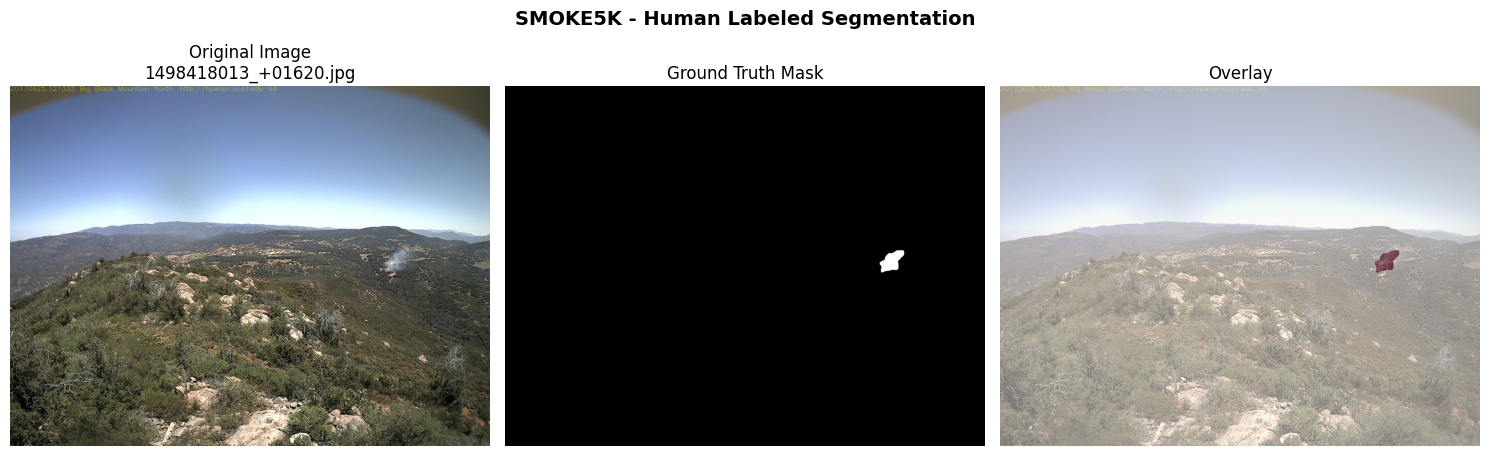

Total images in smoke5k/test: 400


In [13]:
# Smoke5k - Ground Truth Visualization
smoke5k_test_img_path = os.path.join(base_path, "smoke5k/test/img")
smoke5k_test_gt_path = os.path.join(base_path, "smoke5k/test/gt")
# Smoke5k - Ground Truth Visualization

# Get a sample image
img_files = sorted(os.listdir(smoke5k_test_img_path))
sample_img_name = img_files[2]
sample_gt_name = sample_img_name.replace('.jpg', '.png')

img = Image.open(os.path.join(smoke5k_test_img_path, sample_img_name))
gt = Image.open(os.path.join(smoke5k_test_gt_path, sample_gt_name))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title(f"Original Image\n{sample_img_name}")
axes[0].axis('off')

axes[1].imshow(gt, cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[1].axis('off')

axes[2].imshow(img)
axes[2].imshow(np.array(gt), alpha=0.5, cmap='Reds')
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.suptitle("SMOKE5K - Human Labeled Segmentation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total images in smoke5k/test: {len(img_files)}")

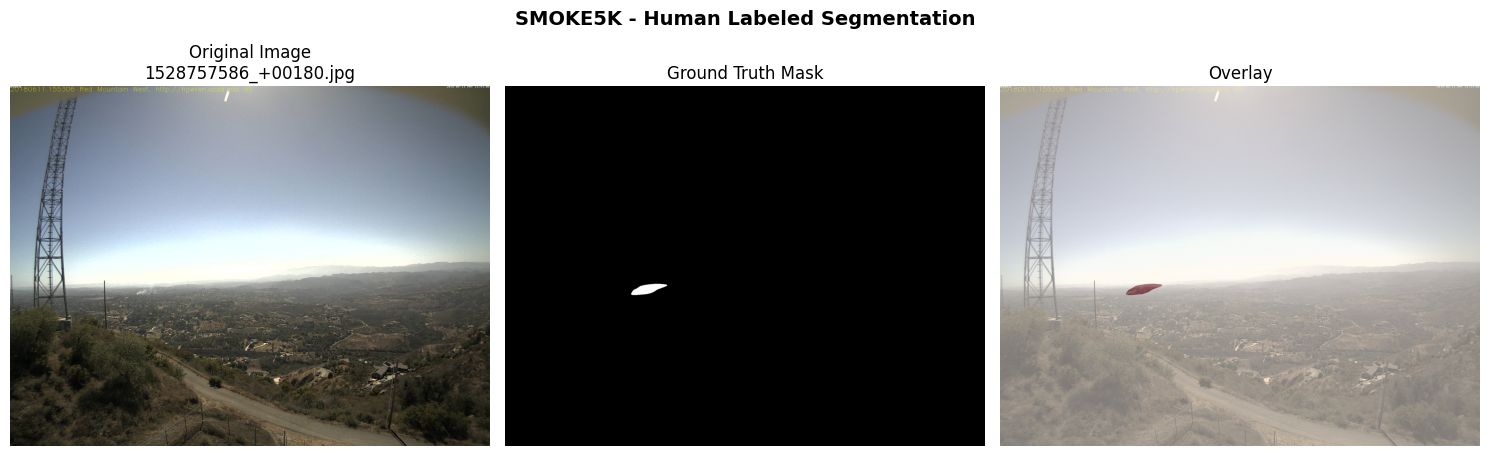

Total images in smoke5k/train: 5058


In [14]:
# Smoke5k - Ground Truth Visualization
smoke5k_train_img_path = os.path.join(base_path, "smoke5k/train/img")
smoke5k_train_gt_path = os.path.join(base_path, "smoke5k/train/gt")

# Get a sample image
img_files = sorted(os.listdir(smoke5k_train_img_path))
sample_img_name = img_files[0]
sample_gt_name = sample_img_name.replace('.jpg', '.png')

img = Image.open(os.path.join(smoke5k_train_img_path, sample_img_name))
gt = Image.open(os.path.join(smoke5k_train_gt_path, sample_gt_name))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title(f"Original Image\n{sample_img_name}")
axes[0].axis('off')

axes[1].imshow(gt, cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[1].axis('off')

axes[2].imshow(img)
axes[2].imshow(np.array(gt), alpha=0.5, cmap='Reds')
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.suptitle("SMOKE5K - Human Labeled Segmentation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total images in smoke5k/train: {len(img_files)}")

In [ ]:
import hashlib
from PIL import Image
import os

# Function to compute image hash (checks if images are identical)
def get_image_hash(image_path):
    """Compute SHA256 hash of image file"""
    sha256_hash = hashlib.sha256()
    with open(image_path, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    return sha256_hash.hexdigest()

# Get all images from train and test directories
smoke5k_train_img_path = os.path.join(base_path, "smoke5k/train/img")
smoke5k_test_img_path = os.path.join(base_path, "smoke5k/test/img")

train_files = sorted(os.listdir(smoke5k_train_img_path))
test_files = sorted(os.listdir(smoke5k_test_img_path))

print(f"Train images: {len(train_files)}")
print(f"Test images: {len(test_files)}")
print(f"Total: {len(train_files) + len(test_files)}")

# Compute hashes for all images
print("\nComputing hashes for train images...")
train_hashes = {}
for fname in train_files:
    fpath = os.path.join(smoke5k_train_img_path, fname)
    try:
        h = get_image_hash(fpath)
        train_hashes[fname] = h
    except Exception as e:
        print(f"  Error hashing {fname}: {e}")

print("Computing hashes for test images...")
test_hashes = {}
for fname in test_files:
    fpath = os.path.join(smoke5k_test_img_path, fname)
    try:
        h = get_image_hash(fpath)
        test_hashes[fname] = h
    except Exception as e:
        print(f"  Error hashing {fname}: {e}")

# Find duplicates: same hash, different name
train_hash_to_names = {}
for fname, h in train_hashes.items():
    if h not in train_hash_to_names:
        train_hash_to_names[h] = []
    train_hash_to_names[h].append(('train', fname))

test_hash_to_names = {}
for fname, h in test_hashes.items():
    if h not in test_hash_to_names:
        test_hash_to_names[h] = []
    test_hash_to_names[h].append(('test', fname))

# Find hashes that appear in both train and test
duplicates = []
for h in train_hash_to_names:
    if h in test_hash_to_names:
        duplicates.append((h, train_hash_to_names[h], test_hash_to_names[h]))

print(f"\n{'='*70}")
print(f"RESULTS: Found {len(duplicates)} identical images in train and test sets")
print(f"{'='*70}")

if duplicates:
    for idx, (h, train_info, test_info) in enumerate(duplicates):
        print(f"\nDuplicate {idx+1}:")
        for split, fname in train_info:
            print(f"  {split}/img/{fname}")
        for split, fname in test_info:
            print(f"  {split}/img/{fname}")
else:
    print("✓ No identical images found between train and test sets!")
    print("  (Train and test sets are cleanly separated)")


## 2. IJMOND_SEG Dataset (Roboflow Human-Annotated)
900 images with COCO-format polygon annotations

In [7]:
ijmond_seg_path = os.path.join(base_path, "ijmond_seg/test")

with open(os.path.join(ijmond_seg_path, "_annotations.coco.json"), 'r') as f:
    coco_data = json.load(f)

# Get first image with annotations
first_img_info = coco_data['images'][0]
img_id = first_img_info['id']
img_name = first_img_info['file_name']

annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_id]
annotations[0]['segmentation'][0], len(annotations[0]['segmentation'][0])

([1346,
  488,
  1346,
  515,
  1350,
  524,
  1346,
  534,
  1352,
  543,
  1348,
  546,
  1345,
  583,
  1357,
  594,
  1372,
  598,
  1374,
  619,
  1398,
  621,
  1424,
  610,
  1454,
  588,
  1462,
  569,
  1476,
  563,
  1477,
  544,
  1469,
  533,
  1475,
  529,
  1474,
  524,
  1479,
  521,
  1481,
  512,
  1476,
  495,
  1461,
  485,
  1460,
  477,
  1456,
  478,
  1452,
  490,
  1434,
  496,
  1416,
  487],
 56)

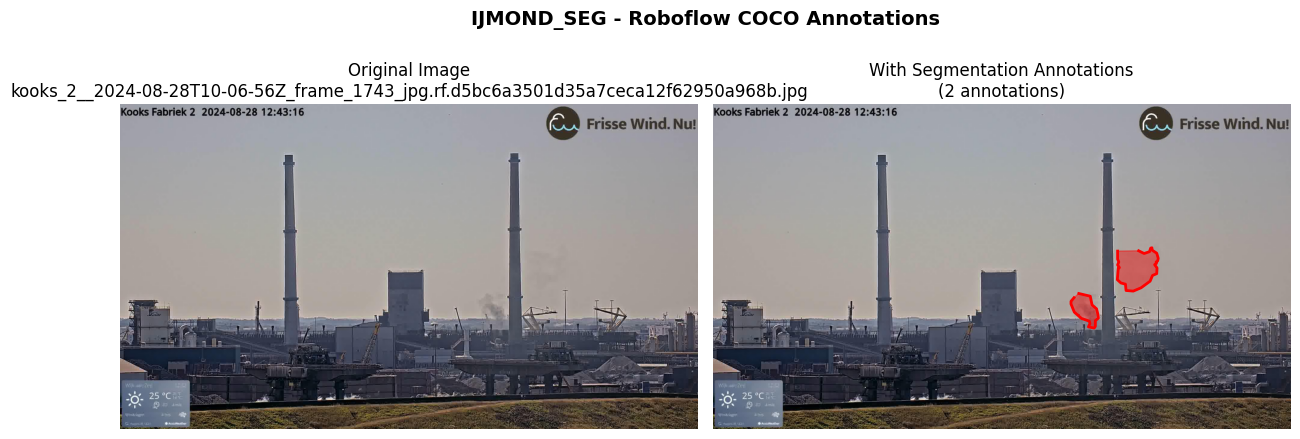

Total images: 900
Categories: ['smoke', 'high-opacity-smoke', 'low-opacity-smoke']


In [8]:
# IJmond_seg - COCO Format Visualization
ijmond_seg_path = os.path.join(base_path, "ijmond_seg/test")

with open(os.path.join(ijmond_seg_path, "_annotations.coco.json"), 'r') as f:
    coco_data = json.load(f)

# Get first image with annotations
first_img_info = coco_data['images'][0]
img_id = first_img_info['id']
img_name = first_img_info['file_name']


# Find annotations for this image
annotations = [a for a in coco_data['annotations'] if a['image_id'] == img_id]

img = Image.open(os.path.join(ijmond_seg_path, "images", img_name))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title(f"Original Image\n{img_name}")
axes[0].axis('off')

# Draw polygon annotations
axes[1].imshow(img)
for ann in annotations:
    seg = ann['segmentation']
    for poly in seg:
        pts = np.array(poly).reshape(-1, 2)
        axes[1].fill(pts[:, 0], pts[:, 1], alpha=0.4, color='red')
        axes[1].plot(pts[:, 0], pts[:, 1], 'r-', linewidth=2)
axes[1].set_title(f"With Segmentation Annotations\n({len(annotations)} annotations)")
axes[1].axis('off')

plt.suptitle("IJMOND_SEG - Roboflow COCO Annotations", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total images: {len(coco_data['images'])}")
print(f"Categories: {[c['name'] for c in coco_data['categories']]}")

## 3. IJMOND_PSEUDO_MASKS (SAM-Generated)
Pseudo masks automatically generated using SAM (Segment Anything Model) from bounding box prompts

In [9]:
# IJmond Pseudo Masks - SAM Generated
pseudo_img_path = os.path.join(base_path, "ijmond_pseudo_masks/img")
pseudo_mask_path = os.path.join(base_path, "ijmond_pseudo_masks/mask")


index = 0 
mask_not_found = True


img_files = sorted(os.listdir(pseudo_img_path))
print(f"Total images in ijmond_pseudo_masks/img: {len(img_files)}")
while mask_not_found and index < len(img_files):
    print(index)
    sample_name = img_files[index]

    img = Image.open(os.path.join(pseudo_img_path, sample_name))

    # Robustly find corresponding mask file (match by stem, allow different extensions)
    mask = None
    expected_mask_path = os.path.join(pseudo_mask_path, sample_name)
    if os.path.exists(expected_mask_path):
        mask = Image.open(expected_mask_path)
    else:
        base_name, _ = os.path.splitext(sample_name)
        if os.path.isdir(pseudo_mask_path):
            mask_candidates = [f for f in os.listdir(pseudo_mask_path) if os.path.splitext(f)[0] == base_name]
            if mask_candidates:
                mask = Image.open(os.path.join(pseudo_mask_path, mask_candidates[0]))
        # try common extensions as a last resort
        if mask is None:
            for ext in (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"):
                p = os.path.join(pseudo_mask_path, base_name + ext)
                if os.path.exists(p):
                    mask = Image.open(p)
                    break

    

    if mask is not None:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img)
        axes[0].set_title(f"Original Image\n{sample_name}")
        axes[0].axis('off')
        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title("SAM-Generated Mask")
        axes[1].axis('off')

        axes[2].imshow(img)
        axes[2].imshow(np.array(mask), alpha=0.5, cmap='Greens')
        axes[2].set_title("Overlay")
        axes[2].axis('off')
        plt.suptitle("IJMOND_PSEUDO_MASKS - SAM Generated from Bounding Boxes", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        mask_not_found = False
    #else:
    #    axes[1].text(0.5, 0.5, "Mask not found", ha='center', va='center', fontsize=12)
    #    axes[1].set_title("SAM-Generated Mask")
    #    axes[1].axis('off')

    #    axes[2].imshow(img)
    #    axes[2].set_title("Overlay\n(no mask)")
    #    axes[2].axis('off')

    index += 1

    


Total images in ijmond_pseudo_masks/img: 610
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
2

## 4. IJMOND_BBOX (Citizen Science Bounding Box Labels)
Raw images with bounding box annotations from IJmondCAM citizen science tool

In [11]:
# IJmond BBox - Citizen Science Bounding Boxes
bbox_img_path = os.path.join(base_path, "ijmond_bbox/img")
bbox_label_path = os.path.join(base_path, "ijmond_bbox/bbox_labels_1_aug_2025.json")

with open(bbox_label_path, 'r') as f:
    bbox_data = json.load(f)

# Find an image with bounding boxes
sample_entry = None

bbox_data['data'][0].keys()

dict_keys(['feedback_filtered', 'file_path', 'frame_number', 'frame_timestamp', 'h_bbox', 'h_image', 'id', 'image_file_name', 'label_state', 'label_state_admin', 'label_update_time', 'mask_file_name', 'url_root', 'video', 'w_bbox', 'w_image', 'x_bbox', 'y_bbox'])

In [12]:
bbox_data['data'][0]['video']

{'camera_id': 1,
 'file_name': 'B6goTCxdTmI-1',
 'id': 312,
 'url_part': 'B6goTCxdTmI',
 'view_id': 1}

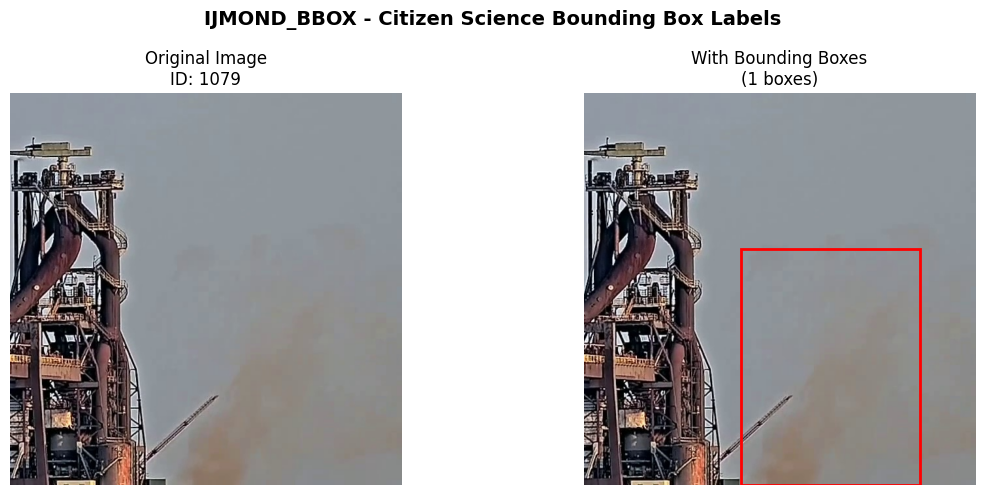

Total entries in bbox JSON: 610
Entries with bboxes: 190


In [13]:
# IJmond BBox - Citizen Science Bounding Boxes
bbox_img_path = os.path.join(base_path, "ijmond_bbox/img")
bbox_label_path = os.path.join(base_path, "ijmond_bbox/filtered_bbox_labels_1_aug_2025.json")

with open(bbox_label_path, 'r') as f:
    bbox_data = json.load(f)

# Find an image with bounding boxes
sample_entry = None
for entry in bbox_data:
    if entry.get('bbox') and len(entry['bbox']) > 0:
        sample_entry = entry
        break

if sample_entry:
    img_name = f"{sample_entry['id']}.png"
    img = Image.open(os.path.join(bbox_img_path, img_name))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img)
    axes[0].set_title(f"Original Image\nID: {sample_entry['id']}")
    axes[0].axis('off')
    
    axes[1].imshow(img)
    for bbox in sample_entry['bbox']:
        # Use the correct key names: x_bbox, y_bbox, w_bbox, h_bbox
        x, y, w, h = bbox['x_bbox'], bbox['y_bbox'], bbox['w_bbox'], bbox['h_bbox']
        rect = plt.Rectangle((x, y), w, h, fill=False, color='red', linewidth=2)
        axes[1].add_patch(rect)
    axes[1].set_title(f"With Bounding Boxes\n({len(sample_entry['bbox'])} boxes)")
    axes[1].axis('off')
    
    plt.suptitle("IJMOND_BBOX - Citizen Science Bounding Box Labels", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Total entries in bbox JSON: {len(bbox_data)}")
    print(f"Entries with bboxes: {sum(1 for e in bbox_data if e.get('bbox') and len(e['bbox']) > 0)}")